# FD Probe Design Script  

## Purpose
1. Import and subset references for custom probe targets.
2. Nominate probes and filter according to 10x custom probe guidelines.
3. Output custom probe order.

#### Author
Written by Jason Swinderman\
Reviewed by Aidan Winters

#### Date
Written November, 8th 2023\
Last revised: December, 4th 2023

#### 10x Custom Guide Design Rules
When designing custom probes for either singleplex or multiplex experiments, consider the following: 

• GC content should be between 44 − 72% for each 25 bp probe half. 

• Avoid homopolymer repeats. 

• Avoid overlap with annotated repeat or low complexity sequences. 

• If possible, design probes for coding regions of mRNA as opposed to untranslated regions. 

• The 25th nucleotide of the probe (3' most nucleotide of the LHS probe) must be a T. The opposing nucleotide in the target RNA must be an A. 

• Avoid common single nucleotide polymorphisms (SNPs) and potential mismatches at the ligation junction. Refer to the UCSC Genome Browser and the Single Nucleotide Polymorphism Database (dbSNP). If avoiding SNPs is not possible, SNPs and mismatches should be at least four bp away from the ligation junction.

• If probes can bind to sequences other than the target mRNA sequence, an off-target signal may be observed. To check for off-target homology, align the probe sequence to the reference transcriptome using the Basic Local Alignment Search Tool (BLAST). Matches to off-target genes should have at least five mismatches in at least one of the LHS or RHS probes to prevent efficient hybridization.

### Dependencies 

In [1]:
from probe_design import *


## Data Import and preprocessing
### subset_domain_fasta() 
    • imports FASTA domain reference
    • Subsets down to desired target list

In [2]:
domain_fasta_ref = "reference/TwistLibrary2.fasta"
pilot_domain_subset = "231130_flex_domain_subset.fasta"

# extract domain sequences from csv reference. 
with open(
    "231130_domain_reference_rev.csv",
    "r",
) as csvfile:
    csvreader = csv.DictReader(csvfile)

    domain_ids = []

    for row in csvreader:
        n_id = row["n_id"]
        c_id = row["c_id"]

        if n_id and c_id:
            domain_ids.append(n_id)
            domain_ids.append(c_id)

subset_domain_fasta(domain_fasta_ref, pilot_domain_subset, domain_ids)

FASTA written to 231130_flex_domain_subset.fasta


## Probe nomination and initial filtering
### nominate_probes() 
    • Reverse complement NTD and CTD sequences
        • Create 50bp bins of the domains
    • Calculate LHS and RHS GC% and score the deviation from 58% GC
    • Calculate the maximum homopolymer length for the LHS and RHS
        • Default permissive first filter of 14 GC% difference from 58% (44%-72%) and homopolymer length 4
        • Added a Shannon entropy calculation and repetitive sequence index to filter out low diversity sequences
        • Creates a pass-filter 50bp-bin FASTA and annotation reference csv

In [3]:
nominate_probes(pilot_domain_subset)

Annotations written to: /Users/gilbertlab/Desktop/Google_Drive/Projects/FlexDomain/Pilot_Domain_Probe_Design/probe_nomination/231130_flex_domain_subset_annotations.csv
Probes written to: /Users/gilbertlab/Desktop/Google_Drive/Projects/FlexDomain/Pilot_Domain_Probe_Design/probe_nomination/231130_flex_domain_subset_probes.fasta
Sequence N34 has 126 potential probe binding sites passing threshold.
Sequence N105 has 91 potential probe binding sites passing threshold.
Sequence N111 has 14 potential probe binding sites passing threshold.
Sequence N131 has 236 potential probe binding sites passing threshold.
Sequence N218 has 83 potential probe binding sites passing threshold.
Sequence N246 has 56 potential probe binding sites passing threshold.
Sequence N252 has 290 potential probe binding sites passing threshold.
Sequence N281 has 12 potential probe binding sites passing threshold.
Sequence N282 has 53 potential probe binding sites passing threshold.
Sequence N284 has 123 potential probe bi

## NCBI BLAST of RHS and LHS probe candidates against reference transcriptome
### lhs_rhs_probe_binding_site_split() 
    • Constructs FASTA of the nominated probe-binding sites for the lhs and rhs sequences. 
    • This is the input for the below shell script(s). It's easiest to run this in commandline. 
### make_hs_refseq_blastdb.sh 
    • Constructs a human refseq blast database 
### flex_domain_probe_blast.sh 
    • BLASTs nominated LHS and RHS probe binding sites and records those with more than 20 bp recognition of sequences in the reference transcriptome

In [5]:
nominated_sites  = "probe_nomination/231130_flex_domain_subset_probes.fasta"
nominated_probes = "probe_nomination/231130_flex_domain_subset_lhs_rhs_probes.fasta"

lhs_rhs_probe_binding_site_split(nominated_sites,nominated_probes)

LHS and RHS probes written to: probe_nomination/231130_flex_domain_subset_lhs_rhs_probes.fasta


## Filter off-target binding probes from BLAST results
### read_blast_results() 
    • imports and subsets blast off-target hits annotating lhs or rhs probes with >20 offtarget priming 
    • annotates each probe with the maximum off-target gene 
### process_lhs_rhs() 
    • concatenates rhs and lhs off-target binding infromation from blast with the probe annotation table from nominate_probes()


In [4]:
len("TTTCCTGTGGCATGTTTCATTCCATGAATATATGCAGTTCCTAGTCCCAA")


50

In [5]:
blast_results = 'probe_nomination/231130_FD_sub_probe_blast.txt'
probe_annotations_csv = 'probe_nomination/231130_flex_domain_subset_annotations.csv'
blast_probe_annotation_output = 'probe_nomination/231130_flex_domain_subset_blast_annotations.csv'

lhs_df, rhs_df = read_blast_results(blast_results)
process_lhs_rhs(lhs_df,rhs_df,probe_annotations_csv,blast_probe_annotation_output)

## Nominating top sets of probes for each target. 
### nominate_top_probe_set() calls:
    • calculate_priority_score() to calculate priority score for each probe pair 
    • nominate_non_overlapping_sets() to generate all unique sets of nonverlapping probe pairs
    • select_highest_priority_sets() to assign the set of probe-pairs with the greatest total priority score. 


In [2]:
blast_probe_annotation = 'probe_nomination/231130_flex_domain_subset_blast_annotations.csv'
nominated_probes = 'probe_nomination/231205_flex_domain_subset_top_probes.csv'
nominate_top_probe_set(blast_probe_annotation,nominated_probes)

## Construct oligo-pool probe order for targets.  
### construct_probe_opool_order() 
    • Requires nominated_probe_csv produced in nominate_top_probe_set()
    • Constructs xlsx that can be directly uploaded to IDT
    • Can adjust number of barcodes to include depending on Flex kit being used

In [ ]:
R2T = "CAGACGTGTGCTCTTCCGATCT"
R2S = "CCTTGGCACCCGAGAATTCCA"


In [2]:
nominated_probe_csv = 'probe_nomination/231203_flex_domain_top_probes.csv'
output_order_name = '231204_flex_domain_probe_oligo_pools_R2T.xlsx'
R2T = "CAGACGTGTGCTCTTCCGATCT"
pool_name_prefix = 'FD_domain_R2N'

construct_probe_opool_order(nominated_probe_csv, output_order_name, R2T, pool_name_prefix, n_barcodes = 4)

In [3]:
nominated_probe_csv = 'probe_nomination/231203_flex_domain_top_probes.csv'
output_order_name = '231204_flex_domain_probe_oligo_pools_R2S.xlsx'
R2S = "CCTTGGCACCCGAGAATTCCA"
pool_name_prefix = 'FD_domain_R2S'

construct_probe_opool_order(nominated_probe_csv, output_order_name, R2S, pool_name_prefix, n_barcodes = 4)

### Check for nonspecificity between probes within pool
- In the case of the domain libraries several termini have overlapping subunits (i.e 'P65-HSF1' and 'P65-MYOD')
- Check whether there is complete homology between any probe candidates 

### Ensure probes are non-overlapping and select top probes
- In the case of the domain libraries several termini have overlapping subunits (i.e 'P65-HSF1' and 'P65-MYOD')
- Check whether there is complete homology between any probe candidates 

In [2]:
gene_names = ["HBG1", "CD55", "CD59", "CXCR4", "MYOD1", "IL2RA"]

gene_to_ensembl_wta_filter(gene_names)


,gene_id,probe_seq,probe_id,included,region
4772,ENSG00000085063,AGTCAGCAGTTGGGTTAGGACAGTTGTAGCACTGCAGGCTATGACC...,ENSG00000085063|CD59|34f2b67,False,unspliced
15000,ENSG00000121966,GGCAGGATAAGGCCAACCATGATGTGCTGAAACTGGAACACAACCA...,ENSG00000121966|CXCR4|3a65ab6,True,unspliced
15001,ENSG00000121966,GGTTGACTGTGTAGATGACATGGACTGCCTTGCATAGGAAGTTCCC...,ENSG00000121966|CXCR4|6b01f36,True,unspliced
15002,ENSG00000121966,ATCCAGACGCCAACATAGACCACCTTTTCAGCCAACAGCTTCCTTG...,ENSG00000121966|CXCR4|92ac59e,True,unspliced
17475,ENSG00000129152,AAACACGGGTCGTCATAGAAGTCGTCCGTTGTGGCAAAGGAGCAGA...,ENSG00000129152|MYOD1|1e85699,True,unspliced
17476,ENSG00000129152,TCGGTGGAGATGCGCTCCACGATGCTGGACAGGCAGTCTAGGCTCG...,ENSG00000129152|MYOD1|3372ec1,True,unspliced
17477,ENSG00000129152,ATTGCTCGACGTGCAGCGCTTGAGTGTCTCAAAGGCCTCATTTACT...,ENSG00000129152|MYOD1|7f6e678,True,unspliced
19678,ENSG00000134460,GAGGTGTCACTTGTTTCGTTGTGTTCCGAGTGGCAGAGCTTGTGCA...,ENSG00000134460|IL2RA|3238490,True,spliced
19679,ENSG00000134460,GGTTGCAGCCATTTCTGTCTGTATTTGAAAATCTGTTGTTGTGACG...,ENSG00000134460|IL2RA|495b656,True,spliced
19680,ENSG00000134460,AGGACGAGTGGCTAGAGTTTCCTGTACAGAGCATATAGAGTGACCC...,ENSG00000134460|IL2RA|b415a6f,True,unspliced


## Comparing custom probe distributions to 10x Human WTA Probe set   
### score_probes()
    • Scoring 10x WTA probe set on QC filters and comparing to custom probe nominations


/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

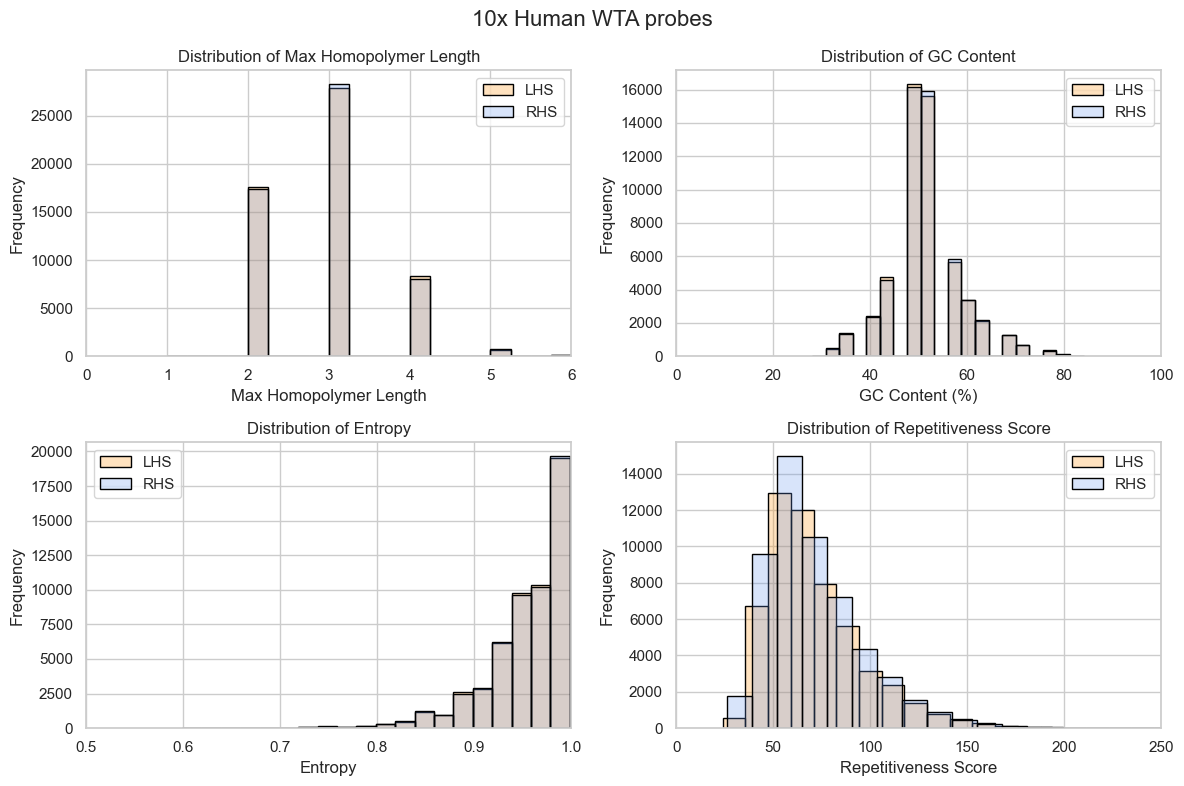

In [4]:
file_path = "reference/Chromium_Human_Transcriptome_Probe_Set_v1.0.1_GRCh38-2020-A.csv"
data = pd.read_csv(file_path, names=['gene_id', 'probe_seq', 'probe_id', 'included', 'region'], skiprows=6)

lhs_sequences = data['probe_seq'].apply(lambda seq: seq[:25])
rhs_sequences = data['probe_seq'].apply(lambda seq: seq[-25:])

    
score_plot_probes(lhs_sequences,rhs_sequences, "10x Human WTA probes")

lhs 58 threshold GC content mean 53.913
rhs 58 threshold GC content mean 55.884
lhs 50 threshold GC content mean 51.536
rhs 50 threshold GC content mean 53.565


/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

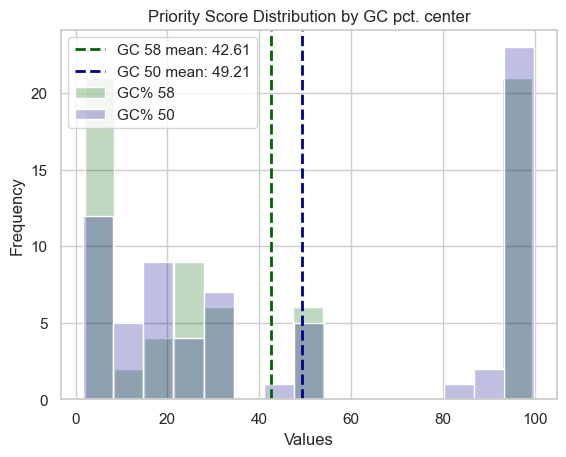

In [26]:
file_path = "probe_nomination/231203_flex_domain_top_probes.csv"
data_58 = pd.read_csv(file_path)
GC_58 = data_58["priority_score"]

file_path = "probe_nomination/231205_flex_domain_subset_top_probes.csv"
data_50 = pd.read_csv(file_path)
GC_50 = data_50["priority_score"]

print("lhs 58 threshold GC content mean",round(data_58["lhs_gc_content"].mean(),3))
print("rhs 58 threshold GC content mean",round(data_58["rhs_gc_content"].mean(),3))
print("lhs 50 threshold GC content mean",round(data_50["lhs_gc_content"].mean(),3))
print("rhs 50 threshold GC content mean",round(data_50["rhs_gc_content"].mean(),3))

sns.set(style="whitegrid")

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt



# Plotting histograms for the two distributions on the same axes
sns.histplot(data=GC_58, bins = 15, color='darkgreen', alpha=0.25, label='GC% 58')
sns.histplot(data=GC_50, bins = 15, color='darkblue', alpha=0.25, label='GC% 50')

# Calculate means
mean1 = GC_58.mean()
mean2 = GC_50.mean()

# Add lines at the mean for each distribution
plt.axvline(mean1, color='darkgreen', linestyle='dashed', linewidth=2, label=f'GC 58 mean: {mean1:.2f}')
plt.axvline(mean2, color='darkblue', linestyle='dashed', linewidth=2, label=f'GC 50 mean: {mean2:.2f}')

# Set labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Priority Score Distribution by GC pct. center')

# Show legend
plt.legend()

# Show the plot
plt.show()


/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/gilbertlab/anaconda3/envs/FD_probe/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

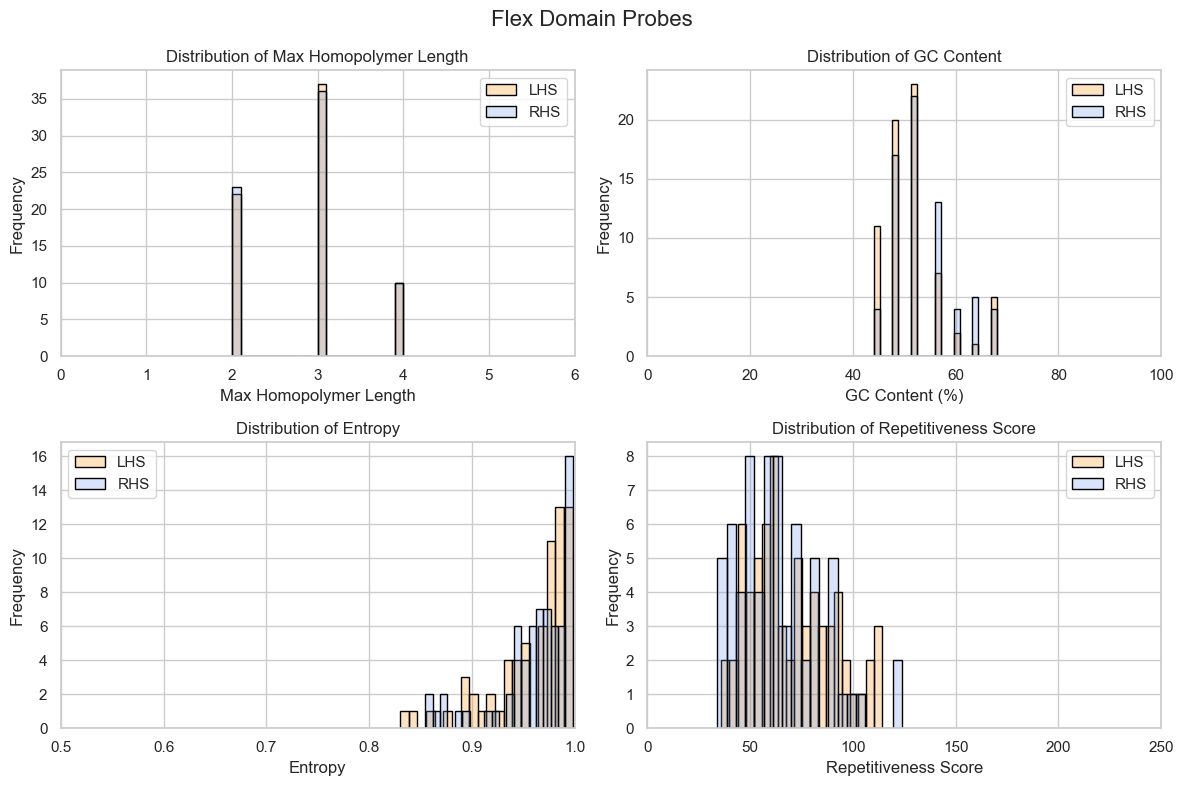

In [5]:
file_path = "probe_nomination/231205_flex_domain_subset_top_probes.csv"
data = pd.read_csv(file_path)

lhs_sequences = data['lhs_sequence'].apply(lambda seq: seq)
rhs_sequences = data['rhs_sequence'].apply(lambda seq: seq)

    
score_plot_probes(lhs_sequences,rhs_sequences, "Flex Domain Probes")